# Original Study: Wave Equation Physics Informed Neural Network (PINN)
Anthony Marinov

## Abstract
Vibrational simulations of cables, governed by the 1D hyperbolic wave equation, are commonly solved using explicit numerical integration. These finite difference approaches are highly optimized, computationally lightweight, and yield near exact solutions to high frequency oscillatory behavior. Recently, Physics-Informed Neural Networks (PINNs) have become a popular and heavily researched, mesh free alternative that allows for continuous, closed-form models. This study explores the practical feasibility of replacing established explicit solvers with a PINN architecture for cable vibration simulation.

The analysis reveals that applying deep learning to hyperbolic PDEs is non-trivial and perhaps computationally disadvantageous. Initial attempts utilizing standard Multi-Layer Perceptrons (MLPs) resulted in failure due to spectral bias and violation of causality. We attempted to mitigate these failure modes by introducing Fourier Feature projection matrices and enforcing a discretized, causal time stepping training loop. The final Causal Fourier PINN demanded significant GPU resources, extensive hyperparameter tuning, and long training times, yet still failed to approach anywhere near the accuracy of the baseline explicit solver. This study demonstrates that for cable wave propagation, there is doubt in the current practical viability of PINNs as a replacement for classical explicit physics solvers.

## Introduction
### 1.1 Background
The vibrational response of continuous cable structures is a key problem in structural mechanics. The propagation of energy through a tensioned material exhibits high frequency oscillatory behavior (governed by the hyperbolic one-dimensional wave equation) that requires precise numerical resolution. Traditionally and commonly, these systems are analyzed using explicit numerical integration schemes, such as the central difference method. These classical finite difference approaches are mathematically mature, optimized for High-Performance Computing (HPC) environments, and lightweight. However, explicit solvers are bound by rigid spatiotemporal (spatial domain and time domain) discretization grids and require strict bounds on time step selection to maintain numerical stability.
### 1.2 Motivation
In recent years, the rapid advancement of scientific machine learning has introduced Physics-Informed Neural Networks (PINNs) as a compelling alternative to classical numerical solvers. PINNs embed the governing partial differential equations (PDEs) along with initial and boundary conditions directly into the loss function of a neural network, and as a result, they theoretically offer a mesh-free, continuously differentiable model. The motivation for adopting PINNs in computational mechanics is the idea of bypassing strict time step bounds and numerical instabilities, enabling continuous spatiotemporal inference without the need for strict numerical stepping. PINNs also can be reused after training with near instantaneous predictions, rather than having to run a relatively computationally expensive numerical integration solver for each inference. While PINNs have demonstrated success in solving elliptic and parabolic PDEs (such as the Navier-Stokes and heat equations), their application to hyperbolic PDE's remains a challenge.
### 1.3 Challengees
Replacing explicit integration with deep learning is non-trivial. When applied to transient wave propagation, standard Multi-Layer Perceptron (MLP) architectures often fail, suffering from trivial solution collapse. This failure is driven by two distinct phenomena. First, neural networks exhibit a spectral bias, inherently preferring to learn smooth, low-frequency functions while failing to resolve the sharp gradients required by the wave equation. Second, standard PINN loss formulations evaluate the spatiotemporal domain globally, which allows the optimizer to average errors across time. This violates causality, allowing future boundary constraints to influence past states and causing the wave energy to rapidly diffuse into a non-physical DC offset.To force a neural network to try to capture these dynamics, architectural changes are required. One approach is using a Fourier Feature Network to transform the training data in an effort to capture higher frequencies. The spatiotemporal coordinates must be projected through a Fourier Feature Network to artificially inject high frequency capabilities, and the training loop must be restricted to discretized chronological windows (Causal Time Stepping) to prevent forward looking error averaging.
### 1.4 Significance and Objectives
The primary objective of this study is to evaluate the practical feasibility of entirely replacing established explicit numerical integration with advanced PINN architectures for cable dynamics. While literature frequently highlights the theoretical benefits of mesh-free deep learning, there is a lack of comparative analysis regarding the actual computational overhead required to achieve parity with classical methods. In this study, we will attempt to benchmark an explicit solver against a Fourier PINN to investigate computational cost and result parity. This work provides practical insight on how the theoretical advantages of deep learning can be overshadowed by the efficiency and reliability of mature explicit physics engines.

## Benchmark Analytical Reference Problem & Solution

### Reference Problem
Obtain the natural frequencies of a uniform string with fixed-free boundary conditions (i.e. fixed at one end and free at the other). The string has mass per unit length $\rho$, internal tension $P$, and length $l$.

### Analytical Solution
#### 1. Wave Equation & General Solution
The 1D wave equation for a string with wave speed $c = \sqrt{\frac{P}{\rho}}$ is:
$$\frac{\partial^2 w}{\partial t^2} = c^2 \frac{\partial^2 w}{\partial x^2}$$
Where $w(x,t)$ is the transverse displacement of the string at position $x$ and time $t$.

Using separation of variables, we assume the solution takes the form $w(x,t) = W(x)T(t)$, where $W(x)$ represents the spatial amplitude (or mode shape) of the string, and $T(t)$ represents the temporal oscillation (how that shape vibrates over time). The general spatial solution is:
$$W(x) = A \cos \frac{\omega x}{c} + B \sin \frac{\omega x}{c}$$

---

#### 2. Applying Boundary Conditions

**Fixed at $x = 0$:**
Displacement is zero.
$$W(0) = A \cos(0) + B \sin(0) = 0 \implies A = 0$$
This leaves: $W(x) = B \sin \frac{\omega x}{c}$

**Free at $x = l$:**
Transverse tension is zero, meaning $\frac{\partial W(l)}{\partial x} = 0$. 
Taking the derivative of our simplified $W(x)$ and evaluating at $x = l$:
$$B \frac{\omega}{c} \cos \frac{\omega l}{c} = 0$$

---

#### 3. Natural Frequencies

For a valid non-zero solution, the cosine term must equal zero:
$$\cos \frac{\omega l}{c} = 0$$

Cosine is zero at odd multiples of $\frac{\pi}{2}$:
$$\frac{\omega l}{c} = \frac{\pi}{2}(2k + 1) \quad \text{for } k = 0, 1, 2, \dots$$

Solving for $\omega$ and substituting $c = \sqrt{\frac{P}{\rho}}$ yields the final natural frequencies:
$$\omega_k = \frac{\pi}{2l}\sqrt{\frac{P}{\rho}}(2k + 1) \quad \text{for } k = 0, 1, 2, \dots$$

### Benchmark Problem: Fixed-Free String

**Parameters:**
* Length ($l$): 1.0 m
* Internal Tension ($P$): 100 N
* Mass per unit length ($\rho$): 0.01 kg/m

#### 1. Wave Speed
$$c = \sqrt{\frac{P}{\rho}} = \sqrt{\frac{100}{0.01}} = 100 \text{ m/s}$$

#### 2. Natural Frequency Equations
$$\omega_k = \frac{c\pi}{2l}(2k + 1)$$

Substitute $c = 100$ and $l = 1.0$ to get the angular frequency (rad/s):
$$\omega_k = 50\pi(2k + 1)$$

Convert to standard frequency in Hertz (Hz):
$$f_k = \frac{\omega_k}{2\pi} = 25(2k + 1)$$

#### 3. Exact Eigenfrequencies (First 4 Modes)
* **Mode 1 (Fundamental, $k=0$):** $f_0 = 25 \text{ Hz}$ ($\omega_0 = 50\pi \approx 157.08 \text{ rad/s}$)
* **Mode 2 ($k=1$):** $f_1 = 75 \text{ Hz}$ ($\omega_1 = 150\pi \approx 471.24 \text{ rad/s}$)
* **Mode 3 ($k=2$):** $f_2 = 125 \text{ Hz}$ ($\omega_2 = 250\pi \approx 785.40 \text{ rad/s}$)
* **Mode 4 ($k=3$):** $f_3 = 175 \text{ Hz}$ ($\omega_3 = 350\pi \approx 1099.56 \text{ rad/s}$)

## Explicit Numerical Simulation

In the analytical solution, we eliminated the time dependency in order to be able to solve for the natural frequencies. We could do the same for the numerical solution (making it Modal Analysis), but to leverage the power of computational mechanics, we will solve this problem more generally by retaining both spatial and time dependencies.

To do this, we will solve the wave PDE generally using Direct Time Integration.

### Direct Time Integration of the 1D Wave Equation

To simulate how a disturbance propagates through the string over time, we use Direct Time Integration. We avoid the assumption of harmonic motion and instead track the transient response by discretizing both space and time.

#### 1. Discretized Wave Equation
The 1D wave equation in terms of wave speed $c = \sqrt{P/\rho}$:
$$\frac{\partial^2 w}{\partial t^2} = c^2 \frac{\partial^2 w}{\partial x^2}$$

We introduce a discrete grid in space ($\Delta x$) and time ($\Delta t$). The displacement at spatial node $i$ and time step $n$ is denoted as $W_i^n$. 

We can apply a second-order central difference approximation to the wave equation:
$$\frac{W_i^{n+1} - 2W_i^n + W_i^{n-1}}{\Delta t^2} = c^2 \frac{W_{i+1}^n - 2W_i^n + W_{i-1}^n}{\Delta x^2}$$

#### 2. Explicit Update Rule
We can rearrange this equation to solve explicitly for the future displacement $W_i^{n+1}$ in terms of the current ($n$) and previous ($n-1$) states. Let $C = c \frac{\Delta t}{\Delta x}$:

$$W_i^{n+1} = 2W_i^n - W_i^{n-1} + C^2 \left( W_{i+1}^n - 2W_i^n + W_{i-1}^n \right)$$

This algebraic update rule is applied iteratively to all internal nodes to advance the simulation forward in time.

#### 3. Boundary Conditions
The boundaries dictate the behavior at the edges of the spatial domain (nodes $1$ and $N$).

* **Fixed End ($x=0$):** Displacement is zero at all times.
    $$W_1^{n+1} = 0$$
* **Free End ($x=l$):** Tension is zero ($\frac{\partial W}{\partial x} = 0$). We enforce this using an additional fake node outside the domain boundary to create a zero slope (first derivatve) at the last node.
    $$W_{N+1}^n = W_{N-1}^n$$

#### 4. Stability Condition
Because this is an explicit integration scheme, numerical stability is conditional. The time step $\Delta t$ must be sufficiently small relative to the grid spacing $\Delta x$ so that information does not travel more than one grid cell per computational time step.

This physical requirement is defined by the Courant-Friedrichs-Lewy (CFL) condition:
$$C = c \frac{\Delta t}{\Delta x} \le 1$$

If this limit is violated ($C > 1$), the explicit numerical solution will become unstable and diverge exponentially.

### Numerical Problem Simulation

We set up the problem as follows:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


# problem params
LENGTH = 1.0 # meters
TENSION = 100.0 # Newtons
DENSITY = 0.01 # kg/m
WAVE_SPEED = np.sqrt(TENSION / DENSITY) # m/s

# spatial params
NUM_NODES = 2000 # number of spatial nodes
SPATIAL_STEP_SIZE = LENGTH / (NUM_NODES - 1)
SPATIAL_DOMAIN = np.arange(0, LENGTH, SPATIAL_STEP_SIZE)

# CFL stability condition
C = 1.0

# time params
TIME_STEP_SIZE = C * SPATIAL_STEP_SIZE / WAVE_SPEED # seconds
TOTAL_TIME = 2.0 # seconds
NUM_TIME_STEPS = int(TOTAL_TIME / TIME_STEP_SIZE)
TIME = np.linspace(0, TOTAL_TIME, NUM_TIME_STEPS)

Because we are solving for the general response of the cable in time, we will not directly get the solution to the natural frequencies of the cable. These can be determinal using signal processing from data collected in the simulation.

In order to see the cable's response across multiple natural frequencies, we will use broadband excitation in the form of a Gaussian pulse to excite multiple frequencies in the cable.

We generate the initial shape of the cable following the Gaussian pulse.

(np.float64(-0.049999999999999996),
 np.float64(1.0499999999999998),
 np.float64(-0.0049999799800250705),
 np.float64(0.10499957958052648))

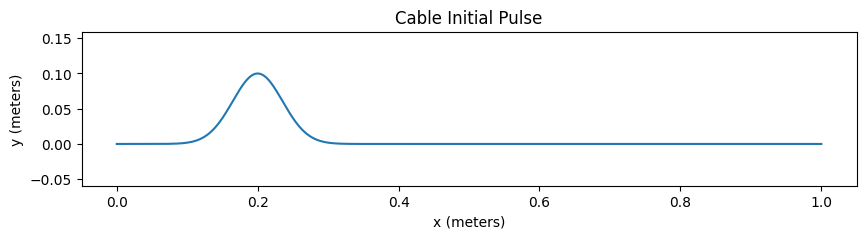

In [2]:
PULSE_MEAN = 0.2
PULSE_SIGMA = 0.05
PULSE_SCALE = 0.1
PULSE = PULSE_SCALE * np.exp(-((SPATIAL_DOMAIN - PULSE_MEAN) / PULSE_SIGMA)**2)

# ensure fixed boundary
PULSE[0] = 0.0

plt.figure(figsize=(10, 2))
plt.plot(SPATIAL_DOMAIN, PULSE)
plt.title('Cable Initial Pulse')
plt.xlabel('x (meters)')
plt.ylabel('y (meters)')
plt.axis('equal')

Now we can go ahead with the explicit time integration from the initial input pulse. The implementation is vectorized for better performance, and uses array slicing rather than explcit loops when looping throught he array points.

In [3]:
# state arrays
W_prev = np.copy(PULSE)
W_curr = np.zeros_like(SPATIAL_DOMAIN)
W_next = np.zeros_like(SPATIAL_DOMAIN)

# time the simulation
start = time.perf_counter()

# first time step (assuming zero initial velocity: v = dw/dt = 0) using approximation
# W1 = W0 + 0.5 * C^2 * (spatial 2nd derivative)
W_curr[1:-1] = W_prev[1:-1] + 0.5 * C**2 * (W_prev[2:] - 2*W_prev[1:-1] + W_prev[:-2])

# apply free boundary condition to first step with fake node
W_curr[-1] = W_prev[-1] + 0.5 * C**2 * (2*W_prev[-2] - 2*W_prev[-1])

# "sensors" to record time history of free end
sensor_data = np.zeros(NUM_TIME_STEPS)
sensor_data[0] = W_prev[-1]
sensor_data[1] = W_curr[-1]

# explicit time integration loop
for n in range(2, NUM_TIME_STEPS):
  # internal node update
  W_next[1:-1] = (2 * W_curr[1:-1] - W_prev[1:-1] + 
      C**2 * (W_curr[2:] - 2 * W_curr[1:-1] + W_curr[:-2]))
  
  # fixed boundary condition
  W_next[0] = 0.0

  # free end update with fake node
  W_next[-1] = (2 * W_curr[-1] - W_prev[-1] + 
      C**2 * (2 * W_curr[-2] - 2 * W_curr[-1]))
  
  # record data
  sensor_data[n] = W_next[-1]

  # update states
  W_prev[:] = W_curr[:]
  W_curr[:] = W_next[:]

end = time.perf_counter()
print(f"Numerical Simulation Time: {end - start:.6f} seconds")

# --- signal processing ---
# compute real fft of sensor time history
fft_result = np.fft.rfft(sensor_data)
fft_mag = np.abs(fft_result)

# frequency bins
freqs = np.fft.rfftfreq(NUM_TIME_STEPS, d=TIME_STEP_SIZE)

# get peaks ignoring DC offset
max_freq_idx = np.searchsorted(freqs, 200)

Numerical Simulation Time: 5.326236 seconds


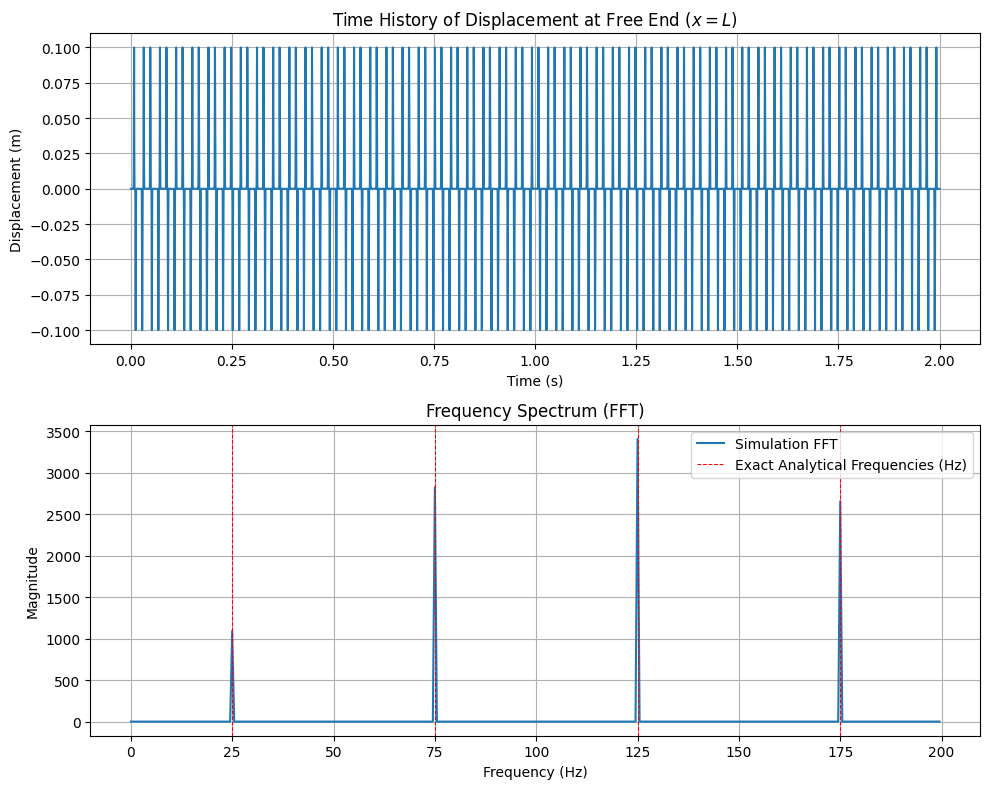

In [4]:
# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# time history
ax1.plot(TIME, sensor_data)
ax1.set_title('Time History of Displacement at Free End ($x=L$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Displacement (m)')
ax1.grid(True)

# frequency spectrum
ax2.plot(freqs[:max_freq_idx], fft_mag[:max_freq_idx], label="Simulation FFT")
ax2.set_title('Frequency Spectrum (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True)
# plot exact analytical frequencies
exact_freqs = [25, 75, 125, 175]
for f in exact_freqs:
  ax2.axvline(f, color='red', linestyle='--', linewidth=0.75,
      label='Exact Analytical Frequencies (Hz)' if f == 25 else "")
ax2.legend()
plt.tight_layout()
plt.show()

As we see, the numerical simulation frequency data matches that calculated analytically. We see the baseline simulation speed using the largest time step size that retains numerical stability for our given cable discretization (2000 nodes) is approximately 5 seconds.

Now we will see if we can train a PINN to replace the explicit integration solver.

## Physics Informed Neural Network (PINN)

### PINN for the 1D Wave Equation

Unlike traditional numerical methods (like Finite Difference or Finite Element Methods) that require discretizing space and time into a rigid grid, a PINN solves partial differential equations in a mesh-free, continuous domain. This methodology leverages the neural network as a universal function approximator governed directly by the underlying physical laws.

#### 1. Continuous Approximation
In a PINN, the unknown displacement field $w(x,t)$ is approximated by a deep neural network, denoted as $w_{NN}$. The network takes continuous spatial coordinates $x$ and continuous time $t$ as direct inputs and outputs the predicted displacement:
$$w_{NN}(x, t) = \mathcal{N}(x, t; \boldsymbol{\theta})$$
Where $\boldsymbol{\theta}$ represents the trainable parameters (weights and biases) of the neural network.

#### 2. Automatic Differentiation (AD)
Traditional solvers use finite difference or other methods to approximate derivatives, which introduce truncation errors and stability limits (like the CFL condition). PINNs avoid this entirely by using Automatic Differentiation (AD). 

AD applies the chain rule recursively to compute the exact analytical derivatives of the network's output with respect to its inputs. This allows us to exactly evaluate the spatial and temporal partial derivatives required by the governing PDE:
* Velocity: $\frac{\partial w_{NN}}{\partial t}$
* Spatial curvature: $\frac{\partial^2 w_{NN}}{\partial x^2}$
* Acceleration: $\frac{\partial^2 w_{NN}}{\partial t^2}$

#### 3. The Composite Loss Function
The network is trained by minimizing a composite loss function that enforces the physics, initial conditions, and boundary conditions evaluated at randomly sampled collocation points within the domain.

**A. The Physics Loss (PDE Residual):**
We sample $N_{PDE}$ collocation points $(x_i, t_i)$ randomly across the spatiotemporal domain. The physics loss penalizes any output that does not satisfy the 1D wave equation ($P \frac{\partial^2 w}{\partial x^2} = \rho \frac{\partial^2 w}{\partial t^2}$):
$$\mathcal{L}_{PDE} = \frac{1}{N_{PDE}} \sum_{i=1}^{N_{PDE}} \left| \rho \frac{\partial^2 w_{NN}(x_i, t_i)}{\partial t^2} - P \frac{\partial^2 w_{NN}(x_i, t_i)}{\partial x^2} \right|^2$$

**B. The Initial Condition (IC) Loss:**
We sample $N_{IC}$ points $(x_j, 0)$ at $t=0$. This loss enforces the initial spatial displacement field $w_0(x)$ and initial velocity $v_0(x)$:
$$\mathcal{L}_{IC} = \frac{1}{N_{IC}} \sum_{j=1}^{N_{IC}} \left( \left| w_{NN}(x_j, 0) - w_0(x_j) \right|^2 + \left| \frac{\partial w_{NN}(x_j, 0)}{\partial t} - v_0(x_j) \right|^2 \right)$$

**C. The Boundary Condition (BC) Loss:**
We sample $N_{BC}$ points at the edges of the spatial domain over time, $(0, t_k)$ and $(l, t_k)$, to enforce the fixed-free constraints:
* **Fixed End ($x=0$):** $w(0,t) = 0$
* **Free End ($x=l$):** $P \frac{\partial w(l,t)}{\partial x} = 0$

$$\mathcal{L}_{BC} = \frac{1}{N_{BC}} \sum_{k=1}^{N_{BC}} \left( \left| w_{NN}(0, t_k) \right|^2 + \left| P \frac{\partial w_{NN}(l, t_k)}{\partial x} \right|^2 \right)$$

#### 4. Training and Optimization
The total loss is the weighted sum of these components:
$$\mathcal{L}_{Total} = \lambda_{PDE}\mathcal{L}_{PDE} + \lambda_{IC}\mathcal{L}_{IC} + \lambda_{BC}\mathcal{L}_{BC}$$
*(Where $\lambda$ terms are hyperparameters used to balance the gradients of the different loss components).*

For better accuracy, an additional loss term $\mathcal{L}_{meas}$ can be introduced to check the solution against measured points. In this case, we will attempt to train the PINN without this additional term, assuming we are unable to make any measurements or generate any fictitious points from analytical solutions.

The network is trained by iteratively updating the parameters $\boldsymbol{\theta}$ using gradient-based optimizers (typically Adam followed by L-BFGS) until $\mathcal{L}_{Total}$ converges near zero. Once trained, the network represents a closed-form, continuous, and fully differentiable analytical approximation of the string's motion.

### PINN Implementation

Here, we set up our PINN parameters and move our core data to the GPU.

In [5]:
import torch


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(DEVICE)
print(f'Device = {torch.get_default_device()}')

Device = cuda:0


Here we define out general PINN class, and the training "dataset" that is specific to and follows the wave equation.

In [6]:
# general PINN class definition with simple network
class PINN(torch.nn.Module):
  def __init__(self, input_dim=2, hidden_dim=64, output_dim=1, num_hidden_layers=4):
    super().__init__()
    layers = [torch.nn.Linear(input_dim, hidden_dim), torch.nn.Tanh()]
    for _ in range(num_hidden_layers - 1):
      layers += [torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.Tanh()]
    layers += [torch.nn.Linear(hidden_dim, output_dim)]
    self.net = torch.nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)
  

# class specific for the wave equation
class WaveEquationDataset(object):
  def __init__(self, n_col, n_ic, n_bc, tension=TENSION, density=DENSITY):
      self.P = tension
      self.rho = density
      self.n_col = n_col # collocation points
      self.n_ic = n_ic # initial-condition points
      self.n_bc = n_bc # boundary-condition points (per boundary)

      # --- collocation points: x in (0,L), t in (0,T) ---
      self.x_c = (LENGTH * torch.rand(n_col, 1)) # (0,1)
      self.t_c = (TOTAL_TIME * torch.rand(n_col, 1)) # (0,2)
      self.Xc = torch.cat((self.x_c, self.t_c), dim=1).requires_grad_(True)
      self.f_target = torch.zeros(self.Xc.shape[0], 1) # PDE residual should = 0

      # --- initial condition points: t = 0, x in (0,L) ---
      self.x_i = torch.linspace(0, LENGTH, n_ic).view(-1, 1) # (0,1)
      self.t_i = torch.zeros_like(self.x_i) # t=0
      self.Xi = torch.cat((self.x_i, self.t_i), dim=1).requires_grad_(True)
      # initial displacement target
      self.Ui = PULSE_SCALE * torch.exp(-((self.x_i - PULSE_MEAN) / PULSE_SIGMA)**2)
      # inital velocity target (v = dw/dt)
      self.Vi = torch.zeros_like(self.Ui)

      # --- boundary points: x = 0 and x = L, t in (0,T) ---
      # fixed left boundary (x = 0)
      self.t_b0 = TOTAL_TIME * torch.rand(self.n_bc, 1) # random times in time domain
      self.x_b0 = torch.zeros_like(self.t_b0) # along x = 0
      self.Xb0 = torch.cat((self.x_b0, self.t_b0), dim=1).requires_grad_(True)
      self.Ub0 = torch.zeros(self.Xb0.shape[0], 1) # target displacement = 0
      # free right boundary (x = L)
      self.t_b1 = TOTAL_TIME * torch.rand(self.n_bc, 1)
      self.x_b1 = (LENGTH * torch.ones_like(self.t_b1))
      self.Xb1 = torch.cat((self.x_b1, self.t_b1), dim=1).requires_grad_(True)
      # we do not define Ub1 here as our target BC is slope = 0

Now we must define the loss function for our PINN.

In [7]:
mseloss = torch.nn.MSELoss()

def pinn_loss(model, dset, mse=mseloss):
  # PDE residual loss
  Xc = dset.Xc
  w_c = model(Xc)

  # first derivatives (w_x, w_t)
  grad_w_c = torch.autograd.grad(
      w_c, Xc,
      grad_outputs=torch.ones_like(w_c),
      create_graph=True
  )[0]
  w_x_c = grad_w_c[:, 0:1]
  w_t_c = grad_w_c[:, 1:2]

  # second spatial derivative (w_xx)
  grad_wx_c = torch.autograd.grad(
      w_x_c, Xc,
      grad_outputs=torch.ones_like(w_x_c),
      create_graph=True
  )[0]
  w_xx_c = grad_wx_c[:, 0:1]
  
  # second temporal derivative (w_tt)
  grad_wt_c = torch.autograd.grad(
      w_t_c, Xc,
      grad_outputs=torch.ones_like(w_t_c),
      create_graph=True
  )[0]
  w_tt_c = grad_wt_c[:, 1:2]

  # scaled residual
  lhs_pde = w_tt_c - w_xx_c
  loss_pde = mse(lhs_pde, dset.f_target)

  # initial condition loss
  Xi = dset.Xi
  w_i = model(Xi)
  
  # enforce initial displacement
  loss_ic_disp = mse(w_i, dset.Ui) 
  
  # enforce initial velocity = 0
  grad_w_i = torch.autograd.grad(
      w_i, Xi,
      grad_outputs=torch.ones_like(w_i),
      create_graph=True
  )[0]
  w_t_i = grad_w_i[:, 1:2]
  loss_ic_vel = mse(w_t_i, dset.Vi)
  
  loss_ic = loss_ic_disp + loss_ic_vel

  # boundary condition loss
  # fixed left boundary (x=0): w = 0
  Xb0 = dset.Xb0
  w_b0 = model(Xb0)
  loss_bc_fixed = mse(w_b0, dset.Ub0) 

  # free right boundary (x=L): dw/dx = 0
  Xb1 = dset.Xb1
  w_b1 = model(Xb1)
  
  grad_w_b1 = torch.autograd.grad(
      w_b1, Xb1,
      grad_outputs=torch.ones_like(w_b1),
      create_graph=True
  )[0]
  w_x_b1 = grad_w_b1[:, 0:1] # spatial slope at x=L
  
  loss_bc_free = mse(w_x_b1, torch.zeros_like(w_x_b1))
  
  loss_bc = loss_bc_fixed + loss_bc_free

  lambda_ic = 100.0
  lambda_bc = 100.0

  return loss_pde + (lambda_ic * loss_ic) + (lambda_bc * loss_bc)

Now we define a training function.

In [32]:
import copy
import gc


def train_pinn(model, dset, lr=1e-1, epochs=2000, use_lbfgs=True, make_plot=True):
  train_losses = np.empty([epochs, 1])
  min_loss = float('inf')
  best_model_state = None

  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  for epoch in range(epochs):
    # adjust learning rate
    if epoch >= 50:
      if epoch % 100 == 0:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.9

    # compute gradient and do the SGD step
    optimizer.zero_grad()
    loss = pinn_loss(model, dset)
    
    # backward pass
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    loss.backward(inputs=trainable_params)
    optimizer.step()

    # track loss
    current_loss_val = loss.detach().cpu().numpy()
    train_losses[epoch] = current_loss_val

    # save weights
    if current_loss_val < min_loss:
      min_loss = current_loss_val
      best_model_state = copy.deepcopy(model.state_dict())

    if epoch % 200 == 0:
      print('Epoch: %d -- Loss: %.5f' % (epoch, current_loss_val))

  if make_plot:
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.plot(train_losses, color='navy')
    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE Loss')
    ax.title.set_text('PINN Training Loss')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.show()

  gc.collect()
  torch.cuda.empty_cache()

  print("Adam optimization complete!")

  # load best weights
  if best_model_state is not None:
    model.load_state_dict(best_model_state)

  # fine tune with second order L-BFGS optimizer
  if use_lbfgs:
    print("Starting L-BFGS optimization.")
    lbfgs_optimizer = torch.optim.LBFGS(
        model.parameters(),
        max_iter=2000,          
        tolerance_grad=1e-7,   
        tolerance_change=1e-9, 
        history_size=50,
        line_search_fn="strong_wolfe"
    )
    
    # L-BFGS requires closure function that re-evaluates model
    def closure():
      lbfgs_optimizer.zero_grad()
      loss = pinn_loss(model, dset)
      trainable_params = [p for p in model.parameters() if p.requires_grad]
      loss.backward(inputs=trainable_params)
      return loss
    
    # run L-BFGS
    lbfgs_optimizer.step(closure)

    final_loss = pinn_loss(model, dset).detach().cpu().item()
    print(f'Final L-BFGS Loss: {final_loss:.7f}')

    # save best weights
    best_model_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_model_state)

  return model

Now we train the model!

/home/anthony/wave-equation-pinn/venv/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 0 -- Loss: 0.78481
Epoch: 200 -- Loss: 0.05556
Epoch: 400 -- Loss: 0.05477
Epoch: 600 -- Loss: 0.05410
Epoch: 800 -- Loss: 0.05347
Epoch: 1000 -- Loss: 0.05290
Epoch: 1200 -- Loss: 0.05252
Epoch: 1400 -- Loss: 0.05232
Epoch: 1600 -- Loss: 0.05219
Epoch: 1800 -- Loss: 0.05210
Epoch: 2000 -- Loss: 0.05203
Epoch: 2200 -- Loss: 0.05197
Epoch: 2400 -- Loss: 0.05192
Epoch: 2600 -- Loss: 0.05188
Epoch: 2800 -- Loss: 0.05185


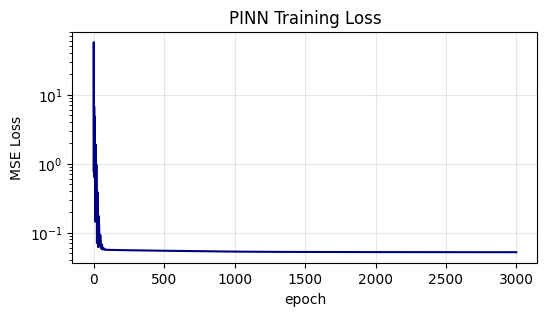

Adam optimization complete!
Starting L-BFGS optimization.
Final L-BFGS Loss: 0.0357093


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): Tanh()
    (8): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [9]:
pinnset = WaveEquationDataset(n_col=5000, n_ic=3000, n_bc=3000)
model = PINN(num_hidden_layers=4, hidden_dim=512)
train_pinn(model, pinnset, lr=5e-4, epochs=3000)

Now that the model is trained, we can use it to replace the numerical integration at each time step.

In [ ]:
model.eval()

t_eval = torch.tensor(TIME, dtype=torch.float32).view(-1, 1).to(DEVICE)

# sensor is fixed at the right boundary (x = LENGTH)
x_eval = (LENGTH * torch.ones_like(t_eval)).to(DEVICE)

# form input to model
X_eval = torch.cat((x_eval, t_eval), dim=1)

# run inference
start = time.perf_counter()
with torch.no_grad(): 
  sensor_data_tensor = model(X_eval)
end = time.perf_counter()
print(f"PINN Inference Time: {end - start:.6f} seconds")

sensor_data = sensor_data_tensor.cpu().numpy().flatten()

# --- signal processing ---
# compute real fft of sensor time history
fft_result = np.fft.rfft(sensor_data)
fft_mag = np.abs(fft_result)

# frequency bins
freqs = np.fft.rfftfreq(NUM_TIME_STEPS, d=TIME_STEP_SIZE)

# get peaks ignoring DC offset
max_freq_idx = np.searchsorted(freqs, 200)

PINN Inference Time: 0.000924 seconds


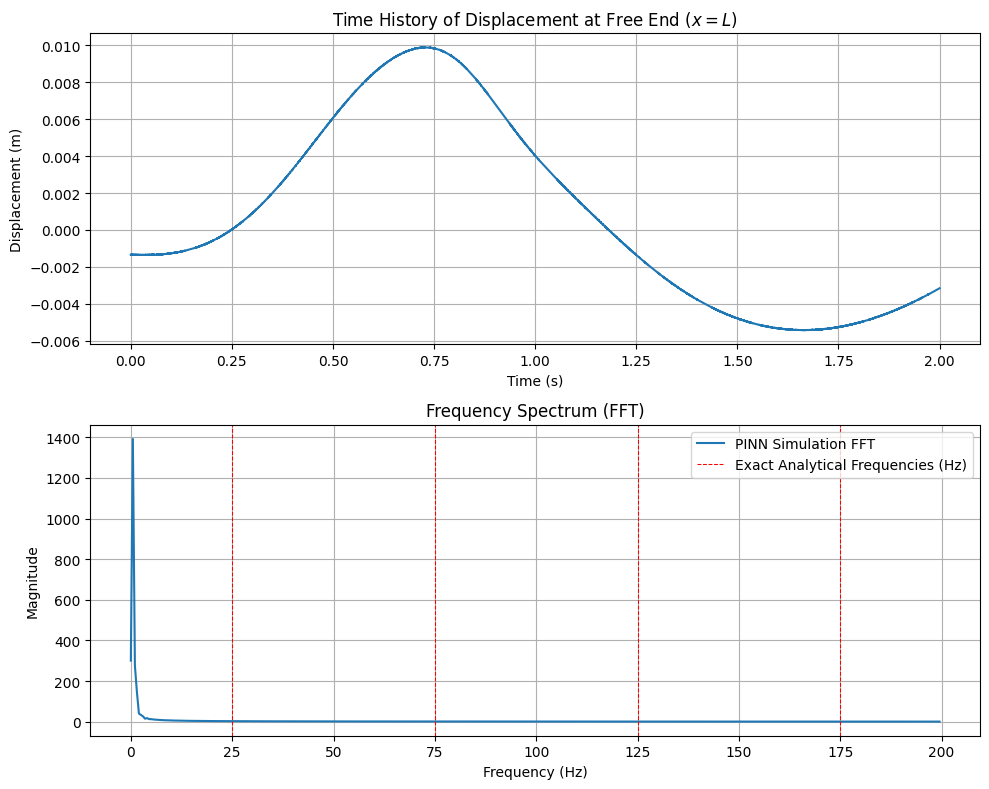

In [11]:
# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# time history
ax1.plot(TIME, sensor_data)
ax1.set_title('Time History of Displacement at Free End ($x=L$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Displacement (m)')
ax1.grid(True)

# frequency spectrum
ax2.plot(freqs[:max_freq_idx], fft_mag[:max_freq_idx], label="PINN Simulation FFT")
ax2.set_title('Frequency Spectrum (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True)
# plot exact analytical frequencies
exact_freqs = [25, 75, 125, 175]
for f in exact_freqs:
  ax2.axvline(f, color='red', linestyle='--', linewidth=0.75,
      label='Exact Analytical Frequencies (Hz)' if f == 25 else "")
ax2.legend()
plt.tight_layout()
plt.show()

As we see above, the results from the PINN are terrible. The PINN only captured some low frequency oscillation in the simulation, completely missing any of the natural cable modes we saw in the explicit numerical simulation and expect from the analytical results. This is a direct result of spectral bias in the standard MLP Neural Network used for this simulation. We also have do not respect time evolution in this simulation, as the PINN is predicting the response of the cable at all times in the simulation at once, which is non-physical.

## Attempting to Improve Performance with Fourier Feature Networks

Standard Multi-Layer Perceptrons (MLPs) are universal function approximators, but they suffer from spectral bias. Neural networks prioritize learning smooth, low-frequency functions and struggle to resolve sharp gradients or high-frequency oscillations. 

When applied to hyperbolic PDEs like the wave equation, this bias is significant. The network typically takes the path of least resistance during optimization, "smearing" the initial condition into a static, highly damped, or entirely flat output (a $0\text{ Hz}$ DC offset) to artificially minimize the sharp gradients associated with the $w_{tt}$ and $w_{xx}$ terms.

To try and bypass this limitation, we project the spatiotemporal input coordinates into a high-dimensional, high-frequency space before they enter the network. In a **Fourier Feature PINN**, the inputs $\mathbf{x} = (x, t)$ are passed through a fixed, random projection matrix $\mathbf{B}$:

$$\gamma(\mathbf{x}) = [\cos(2\pi \mathbf{B}\mathbf{x}), \sin(2\pi \mathbf{B}\mathbf{x})]^T$$

The matrix $\mathbf{B}$ is sampled from a normal distribution scaled by a hyperparameter $\sigma$, which acts as a frequency dial. By tuning $\sigma$ to encompass the physical natural frequencies of the system, the network is forced to see high-frequency oscillations, hopefully mitigating spectral bias and allowing the optimizer to capture complex standing wave dynamics.

In [ ]:
class PINN_Fourier(torch.nn.Module):
  def __init__(self, input_dim=2, hidden_dim=128, output_dim=1, 
      num_hidden_layers=6, fourier_features=128, sigma=10.0):
    super().__init__()
    # fourier feature projection matrix
    # we freeze these weights. they are randomly initialized and not trained
    self.B = torch.nn.Parameter(torch.randn(input_dim, fourier_features) * sigma, 
        requires_grad=False)
    
    # build network
    layers = [torch.nn.Linear(fourier_features * 2, hidden_dim), torch.nn.Tanh()]
    for _ in range(num_hidden_layers - 1):
      layers += [torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.Tanh()]
    layers += [torch.nn.Linear(hidden_dim, output_dim)]
    
    self.net = torch.nn.Sequential(*layers)

  def forward(self, x):
    # project inputs into fourier space
    x_proj = 2.0 * torch.pi * x @ self.B
    # concatenate sine and cos projections
    x_fourier = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
    
    return self.net(x_fourier)

### Causality with Time-Stepping

A flaw of the standard PINN loss formulation is that it evaluates the entire spatiotemporal domain simultaneously. The composite loss function calculates the PDE residual globally, meaning the network does not understand that the state of a system at $t_{n+1}$ must be a direct, physical consequence of its state at $t_n$. 

Without a strict evolution of time, the optimizer frequently discovers non-physical shortcuts. It will average out errors across the entire domain, violating causality by allowing future boundary constraints to heavily influence past states, often resulting in a trivial solution.

To try and fix this, we employ a **Time Stepping (or Causal) Training Strategy**. This mimics the sequential nature of explicit numerical physics solvers while retaining the mesh-free, continuous differentiation of a neural network:

1. **Domain Discretization:** The total simulation time $T$ is divided into small, chronological windows of size $\Delta t$. This window ensures the network only has to predict a fraction of a physical wave cycle at a time.
2. **Sequential Optimization:** The PINN is trained exclusively on the first window, $t \in [0, \Delta t]$, subject to the true analytical initial conditions.
3. **State Handoff:** Once converged, the network's continuous predictions for displacement and velocity at the end of the window, $w(x, \Delta t)$ and $w_t(x, \Delta t)$, are extracted via automatic differentiation and frozen. 
4. **Causal Progression:** These frozen outputs become the initial condition constraints for the next time window $t \in [\Delta t, 2\Delta t]$.

By stepping forward through time, we hopefully eliminate global error averaging and force the network to respect the physical propagation of energy through the structure.

We redefine the equation dataset to enable the time-stepping training approach.

In [ ]:
import math

class WaveEquationDataset:
  def __init__(self, n_col, n_bc, n_ic, t_min=0.0, t_max=0.005, 
    tension=100.0, density=0.01, ic_model=None):
    self.P = tension
    self.rho = density
    self.c = math.sqrt(self.P / self.rho) # c = 100.0

    # scale time bounds
    tau_min = t_min * self.c
    tau_max = t_max * self.c

    # collocation points
    x_c = LENGTH * torch.rand(n_col, 1)
    tau_c = tau_min + (tau_max - tau_min) * torch.rand(n_col, 1)
    self.Xc = torch.cat((x_c, tau_c), dim=1).requires_grad_(True)
    self.f_target = torch.zeros(self.Xc.shape[0], 1)

    # boundary points
    tau_b0 = tau_min + (tau_max - tau_min) * torch.rand(n_bc, 1)
    x_b0 = torch.zeros_like(tau_b0)
    self.Xb0 = torch.cat((x_b0, tau_b0), dim=1).requires_grad_(True)
    self.Ub0 = torch.zeros(self.Xb0.shape[0], 1)

    tau_b1 = tau_min + (tau_max - tau_min) * torch.rand(n_bc, 1)
    x_b1 = LENGTH * torch.ones_like(tau_b1)
    self.Xb1 = torch.cat((x_b1, tau_b1), dim=1).requires_grad_(True)

    # initial condition points
    x_i = torch.linspace(0, LENGTH, n_ic).view(-1, 1)
    tau_i = torch.full_like(x_i, tau_min) 
    self.Xi = torch.cat((x_i, tau_i), dim=1).requires_grad_(True)

    if ic_model is None:
      PULSE_SCALE = 1.0 
      PULSE_MEAN = 0.2
      PULSE_SIGMA = 0.05
      self.Ui = PULSE_SCALE * torch.exp(-((x_i - PULSE_MEAN) / PULSE_SIGMA)**2)
      self.Vi = torch.zeros_like(self.Ui) 
    else:
      Xi_temp = torch.cat((x_i, tau_i), dim=1).requires_grad_(True)
      Ui_pred = ic_model(Xi_temp)
      
      grad_u = torch.autograd.grad(
          Ui_pred, Xi_temp,
          grad_outputs=torch.ones_like(Ui_pred),
          create_graph=False, 
          retain_graph=False
      )[0]
      # Vi target remains exactly 0
      Vi_pred = grad_u[:, 1:2] 
      
      self.Ui = Ui_pred.detach()
      self.Vi = Vi_pred.detach()

We train the model across time steps now.

--- Training Time Window 1/20: t = [0.00, 0.10] ---
Epoch: 0 -- Loss: 5615891968.00000
Epoch: 200 -- Loss: 8124.78857
Epoch: 400 -- Loss: 1981.43994
Epoch: 600 -- Loss: 1954.88977
Epoch: 800 -- Loss: 1929.28601
Epoch: 1000 -- Loss: 1905.15137


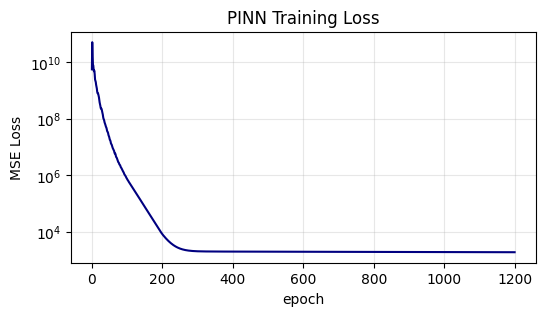

Adam optimization complete!
Starting L-BFGS optimization.
Final L-BFGS Loss: 439.9551392
--- Training Time Window 2/20: t = [0.10, 0.20] ---
Epoch: 0 -- Loss: 4144609.50000
Epoch: 200 -- Loss: 3807.46704
Epoch: 400 -- Loss: 412.19275
Epoch: 600 -- Loss: 408.26660
Epoch: 800 -- Loss: 405.09320


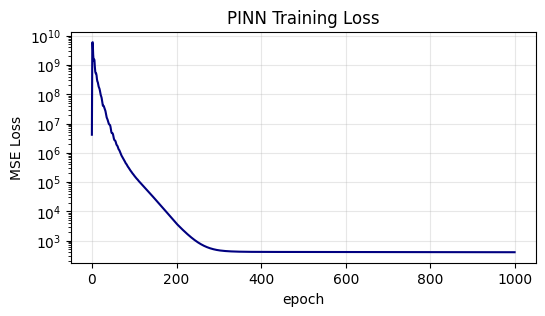

Adam optimization complete!
--- Training Time Window 3/20: t = [0.20, 0.30] ---
Epoch: 0 -- Loss: 3505241.25000
Epoch: 200 -- Loss: 4186.21582
Epoch: 400 -- Loss: 231.99423
Epoch: 600 -- Loss: 227.66281
Epoch: 800 -- Loss: 226.29961


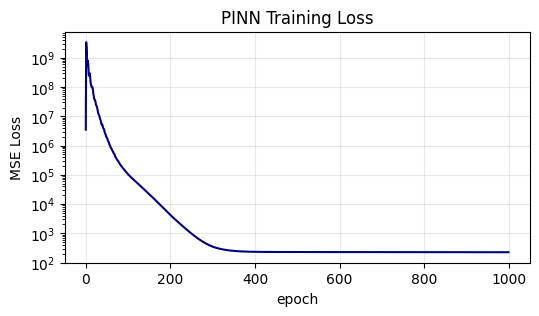

Adam optimization complete!
--- Training Time Window 4/20: t = [0.30, 0.40] ---
Epoch: 0 -- Loss: 1468994.37500
Epoch: 200 -- Loss: 3890.33301
Epoch: 400 -- Loss: 88.71914
Epoch: 600 -- Loss: 71.47448
Epoch: 800 -- Loss: 70.05470


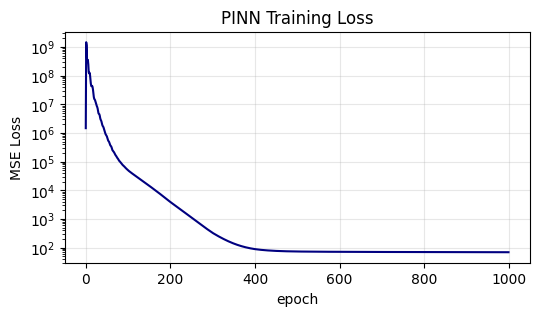

Adam optimization complete!
--- Training Time Window 5/20: t = [0.40, 0.50] ---
Epoch: 0 -- Loss: 504301.56250
Epoch: 200 -- Loss: 4183.88330
Epoch: 400 -- Loss: 124.91440
Epoch: 600 -- Loss: 25.17428
Epoch: 800 -- Loss: 22.39296


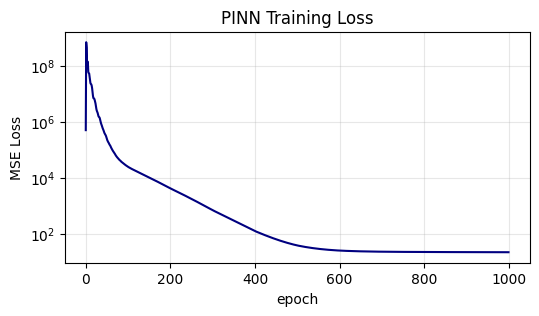

Adam optimization complete!
--- Training Time Window 6/20: t = [0.50, 0.60] ---
Epoch: 0 -- Loss: 134988.43750
Epoch: 200 -- Loss: 3629.23926
Epoch: 400 -- Loss: 356.22015
Epoch: 600 -- Loss: 37.71439
Epoch: 800 -- Loss: 9.79815


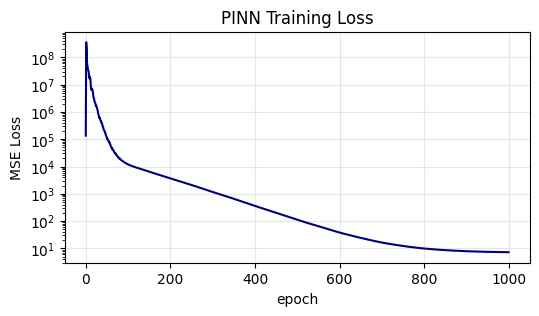

Adam optimization complete!
--- Training Time Window 7/20: t = [0.60, 0.70] ---
Epoch: 0 -- Loss: 39692.18359
Epoch: 200 -- Loss: 1729.15015
Epoch: 400 -- Loss: 255.95731
Epoch: 600 -- Loss: 37.70526
Epoch: 800 -- Loss: 7.93235


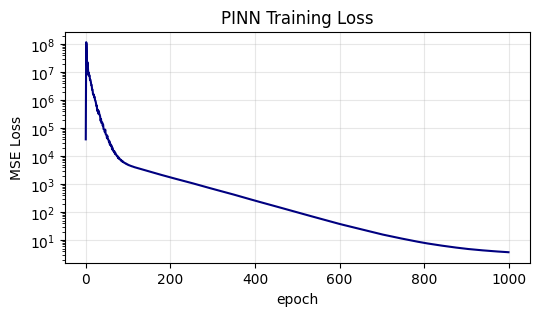

Adam optimization complete!
--- Training Time Window 8/20: t = [0.70, 0.80] ---
Epoch: 0 -- Loss: 13811.78125
Epoch: 200 -- Loss: 553.72675
Epoch: 400 -- Loss: 21.47346
Epoch: 600 -- Loss: 2.26951
Epoch: 800 -- Loss: 1.66660


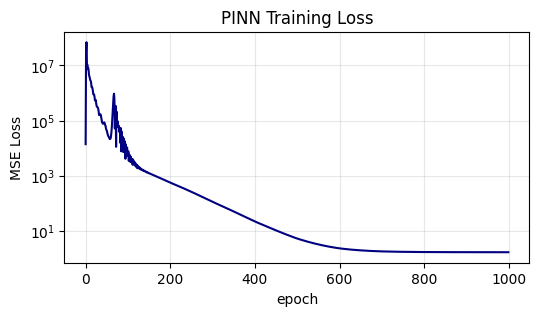

Adam optimization complete!
--- Training Time Window 9/20: t = [0.80, 0.90] ---
Epoch: 0 -- Loss: 12770.12793
Epoch: 200 -- Loss: 346.64462
Epoch: 400 -- Loss: 39.28336
Epoch: 600 -- Loss: 3.00257
Epoch: 800 -- Loss: 1.58417


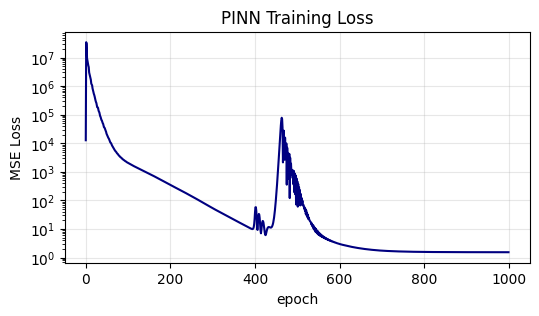

Adam optimization complete!
--- Training Time Window 10/20: t = [0.90, 1.00] ---
Epoch: 0 -- Loss: 9613.93359
Epoch: 200 -- Loss: 335.53412
Epoch: 400 -- Loss: 574.02985
Epoch: 600 -- Loss: 4.33245
Epoch: 800 -- Loss: 1.27463


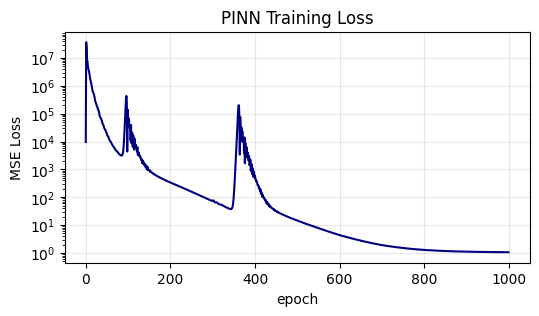

Adam optimization complete!
--- Training Time Window 11/20: t = [1.00, 1.10] ---
Epoch: 0 -- Loss: 6978.61475
Epoch: 200 -- Loss: 63003.01172
Epoch: 400 -- Loss: 5.71816
Epoch: 600 -- Loss: 4708.48486
Epoch: 800 -- Loss: 1.95529


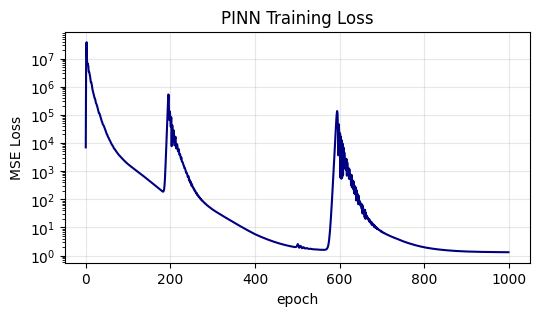

Adam optimization complete!
--- Training Time Window 12/20: t = [1.10, 1.20] ---
Epoch: 0 -- Loss: 10513.87500
Epoch: 200 -- Loss: 2003.04175
Epoch: 400 -- Loss: 16.04084
Epoch: 600 -- Loss: 1.75554
Epoch: 800 -- Loss: 1.10568


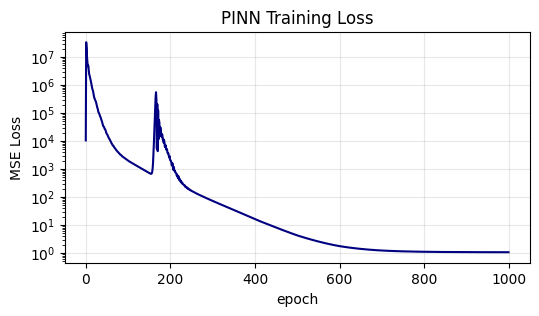

Adam optimization complete!
--- Training Time Window 13/20: t = [1.20, 1.30] ---
Epoch: 0 -- Loss: 7721.18213
Epoch: 200 -- Loss: 253.95088
Epoch: 400 -- Loss: 10.92734
Epoch: 600 -- Loss: 7214.38916
Epoch: 800 -- Loss: 2.51868


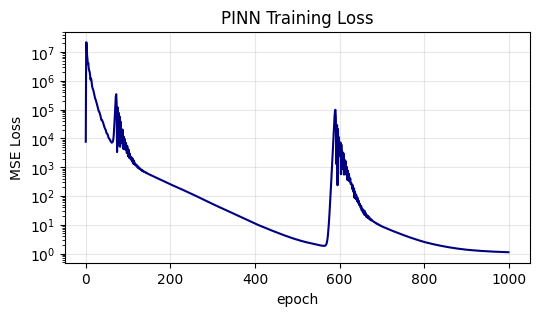

Adam optimization complete!
--- Training Time Window 14/20: t = [1.30, 1.40] ---
Epoch: 0 -- Loss: 6381.95605
Epoch: 200 -- Loss: 3825.83081
Epoch: 400 -- Loss: 11.07467
Epoch: 600 -- Loss: 1.45953
Epoch: 800 -- Loss: 0.80974


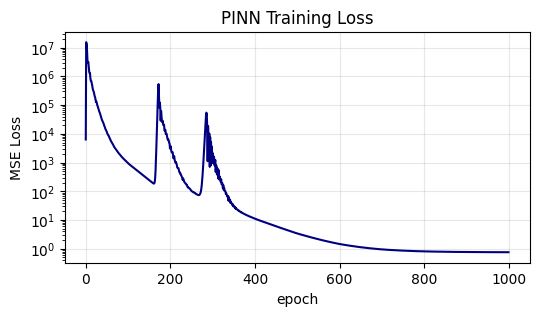

Adam optimization complete!
--- Training Time Window 15/20: t = [1.40, 1.50] ---
Epoch: 0 -- Loss: 4404.17480
Epoch: 200 -- Loss: 148.57904
Epoch: 400 -- Loss: 198.51472
Epoch: 600 -- Loss: 1.32160
Epoch: 800 -- Loss: 0.97050


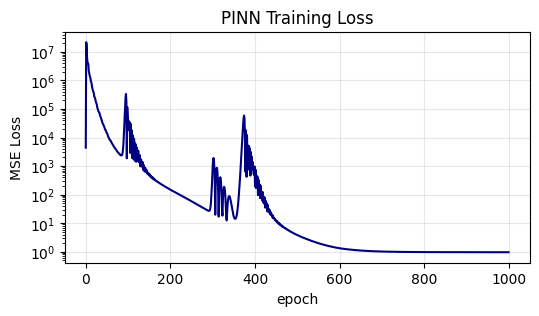

Adam optimization complete!
--- Training Time Window 16/20: t = [1.50, 1.60] ---
Epoch: 0 -- Loss: 8154.84570
Epoch: 200 -- Loss: 38418.69531
Epoch: 400 -- Loss: 8.58843
Epoch: 600 -- Loss: 1.39626
Epoch: 800 -- Loss: 0.99839


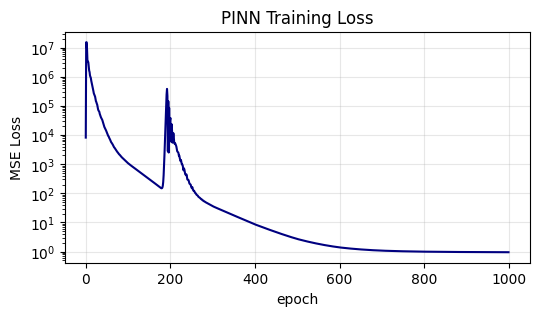

Adam optimization complete!
--- Training Time Window 17/20: t = [1.60, 1.70] ---
Epoch: 0 -- Loss: 5579.44971
Epoch: 200 -- Loss: 4713.13330
Epoch: 400 -- Loss: 223.96599
Epoch: 600 -- Loss: 1.15926
Epoch: 800 -- Loss: 0.84976


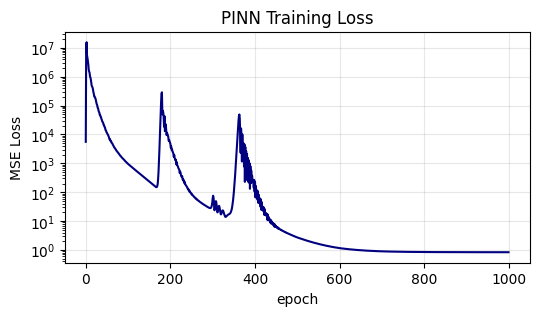

Adam optimization complete!
--- Training Time Window 18/20: t = [1.70, 1.80] ---
Epoch: 0 -- Loss: 6008.64014
Epoch: 200 -- Loss: 1908.86340
Epoch: 400 -- Loss: 2.22024
Epoch: 600 -- Loss: 5.55194
Epoch: 800 -- Loss: 1.05339


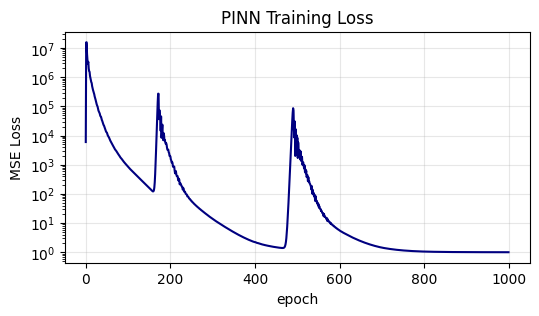

Adam optimization complete!
--- Training Time Window 19/20: t = [1.80, 1.90] ---
Epoch: 0 -- Loss: 7638.72607
Epoch: 200 -- Loss: 2159.94067
Epoch: 400 -- Loss: 1.75546
Epoch: 600 -- Loss: 1.26842
Epoch: 800 -- Loss: 1.26228


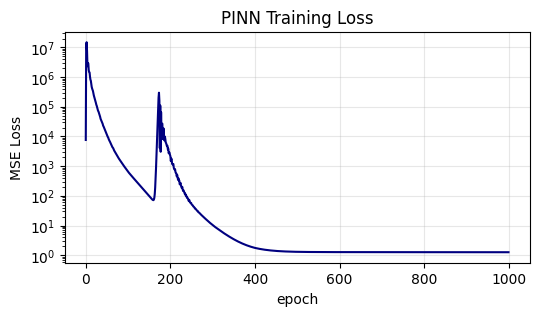

Adam optimization complete!
--- Training Time Window 20/20: t = [1.90, 2.00] ---
Epoch: 0 -- Loss: 9684.86230
Epoch: 200 -- Loss: 9602.69141
Epoch: 400 -- Loss: 1.97760
Epoch: 600 -- Loss: 1.66461
Epoch: 800 -- Loss: 1.65749
Epoch: 1000 -- Loss: 1.65103


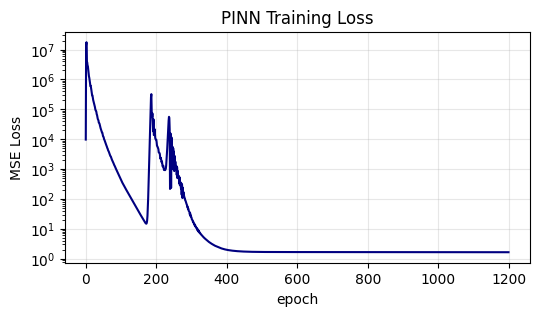

Adam optimization complete!
Starting L-BFGS optimization.
Final L-BFGS Loss: 1.6449680


In [ ]:
TOTAL_TIME = 2.0
WINDOW_SIZE = 0.1
NUM_WINDOWS = int(TOTAL_TIME / WINDOW_SIZE)

N_COL = 5000
N_BC = 4000
N_IC = 4000

model = PINN_Fourier(
    input_dim=2, 
    hidden_dim=1024, 
    output_dim=1, 
    num_hidden_layers=3,
    fourier_features=512, # number of frequency bands to generate
    sigma=120.0 # frequency scaling factor
)

for step in range(NUM_WINDOWS):
  t_start = step * WINDOW_SIZE
  t_end = (step + 1) * WINDOW_SIZE
  print(f"--- Training Time Window {step+1}/{NUM_WINDOWS}: t = [{t_start:.2f}, {t_end:.2f}] ---")

  # dynamically generate dataset for window
  if step == 0:
    # window 1: use  exact Gaussian pulse
    current_dset = WaveEquationDataset(
        n_col=N_COL,
        n_bc=N_BC,
        n_ic=N_IC,
        t_min=t_start, 
        t_max=t_end, 
        ic_model=None 
    )
  else:
    # window 2+: pass current model in to generate the new intitial conditions
    current_dset = WaveEquationDataset(
        n_col=N_COL,
        n_bc=N_BC,
        n_ic=N_IC,
        t_min=t_start, 
        t_max=t_end, 
        ic_model=model 
    )
  
  if step == 0 or step == NUM_WINDOWS - 1:
    model = train_pinn(model, current_dset, lr=5e-4, epochs=1200)
  else:
    model = train_pinn(model, current_dset, lr=5e-4, epochs=1000, use_lbfgs=False)

In [ ]:
model.eval()

t_eval = torch.tensor(TIME, dtype=torch.float32).view(-1, 1).to(DEVICE)

# sensor is fixed at the right boundary (x = LENGTH)
x_eval = (LENGTH * torch.ones_like(t_eval)).to(DEVICE)

# form input to model
X_eval = torch.cat((x_eval, t_eval), dim=1)

# run inference
start = time.perf_counter()
with torch.no_grad(): 
  sensor_data_tensor = model(X_eval)
end = time.perf_counter()
print(f"PINN Inference Time: {end - start:.6f} seconds")

sensor_data = sensor_data_tensor.cpu().numpy().flatten()

# --- signal processing ---
# compute real fft of sensor time history
fft_result = np.fft.rfft(sensor_data)
fft_mag = np.abs(fft_result)

# frequency bins
freqs = np.fft.rfftfreq(NUM_TIME_STEPS, d=TIME_STEP_SIZE)

# get peaks ignoring DC offset
max_freq_idx = np.searchsorted(freqs, 200)

PINN Inference Time: 0.001508 seconds


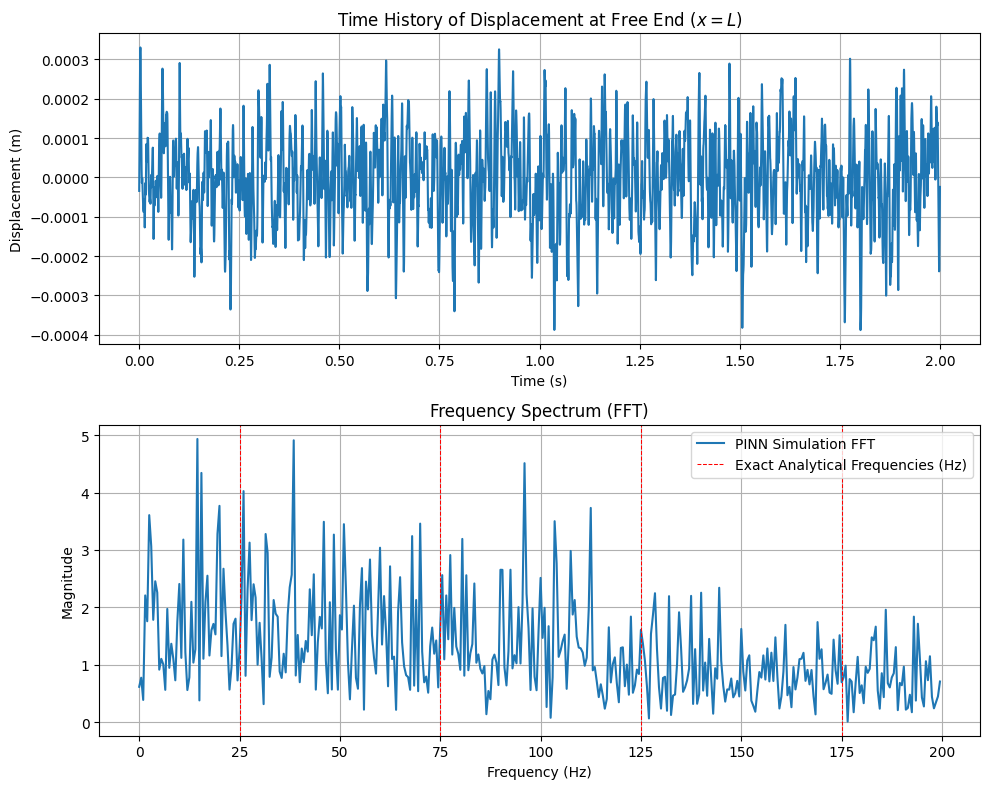

In [56]:
# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# time history
ax1.plot(TIME, sensor_data)
ax1.set_title('Time History of Displacement at Free End ($x=L$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Displacement (m)')
ax1.grid(True)

# frequency spectrum
ax2.plot(freqs[:max_freq_idx], fft_mag[:max_freq_idx], label="PINN Simulation FFT")
ax2.set_title('Frequency Spectrum (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True)
# plot exact analytical frequencies
exact_freqs = [25, 75, 125, 175]
for f in exact_freqs:
  ax2.axvline(f, color='red', linestyle='--', linewidth=0.75,
      label='Exact Analytical Frequencies (Hz)' if f == 25 else "")
ax2.legend()
plt.tight_layout()
plt.show()

## Conclusion

This study aimed to evaluate the feasibility of replacing mature explicit numerical integration solvers with Physics-Informed Neural Networks (PINNs) for simulating the vobrational response of cables. While the theoretical appeal of a continuous, mesh-free model is significant, the practical application of deep learning to hyperbolic systems like the 1D wave equation reveals fundamental and computational limitations.

The findings demonstrate that standard Multi-Layer Perceptron (MLP) architectures are unable to handle high-frequency wave propagation. The network's vulnerability to spectral bias and the non-causal evaluation of the standard PINN loss function resulted in violation of physical causality and created non-physical trivial solutions. After this, we significantly modified the neural network in an effort to capture more oscillatory dynamics by mapping spatial and temporal coordinates through a Fourier Feature projection matrix to try to bypass spectral bias. We also implemented a discretized, causal time-stepping training loop to attempt to prevent forward-looking error averaging.

However, the resulting Fourier PINN required significant hyperparameter tuning and extensive GPU training time while still producing innaccurate solutions which essentially resemble random noise in the frequency domain. On the other hand, the baseline explicit integration method yeilded near perfect wave resolution with only a few seconds of computation time. While inference with the PINN is many orders of magnitude faster than the epxlicit time integration, the extensive training and tuning time as well as the poor results make it impractical for this use case.

Ultimately, we conclude that PINNs likely do not currently offer a practical advantage over classical methods for cable vibration simulations, at least using the strategies tested in this analysis. The overhead and resource intensity required to force a neural network to mimic the results of a lightweight finite difference method render it inefficient. PINNs still remain a powerful tool for inverse problem solving, parameter discovery, and handling some PDEs, but explicit numerical solvers likely remain the superior and more efficient tool for modeling continuous hyperbolic wave propagation.

## References
- **Hughes, T. J. R. (2012).** The Finite Element Method: Linear Static and Dynamic Finite Element Analysis. Dover Publications.
- **LeVeque, R. J. (2007).** Finite Difference Methods for Ordinary and Partial Differential Equations: Steady-State and Time-Dependent Problems. Society for Industrial and Applied Mathematics (SIAM).
- **Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019).** Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, 378, 686-707.
- **Karniadakis, G. E., Kevrekidis, I. G., Lu, L., Perdikaris, P., Wang, S., & Yang, L. (2021).** Physics-informed machine learning. Nature Reviews Physics, 3(6), 422-440.